# Analisis Klasterisasi Kerentanan Banjir di Jawa Barat (2015–2023)

Notebook ini bertujuan untuk mengelompokkan wilayah (kabupaten/kota) di Jawa Barat berdasarkan tingkat kerentanannya terhadap banjir menggunakan metode **K-Means Clustering**.

### Tujuan Analisis
1. Menentukan tingkat kerentanan banjir (Rendah, Sedang, Tinggi) untuk setiap wilayah dan tahun (2015–2023).
2. Mengevaluasi kualitas klasterisasi secara objektif menggunakan metrik evaluasi seperti *Within-Cluster Sum of Squares* (Elbow Method), *Silhouette Coefficient*, *Calinski-Harabasz Index*, dan *Davies-Bouldin Index*.
3. Menganalisis karakteristik/profil dari masing-masing klaster untuk memahami faktor pendorong utama kerentanan banjir di setiap kelompok.
4. Memberikan visualisasi yang interaktif dan informatif (*premium aesthetics*) untuk laporan analisis.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Mengatur tema visual Matplotlib & Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Pencarian path input & output secara dinamis agar aman dijalankan dari root maupun folder notebooks/
if Path("data/processed/MASTER_MERGED_CLEANED_DASHBOARD.csv").exists():
    INPUT_PATH = Path("data/processed/MASTER_MERGED_CLEANED_DASHBOARD.csv")
    OUTPUT_DIR = Path("data/processed")
else:
    INPUT_PATH = Path("../data/processed/MASTER_MERGED_CLEANED_DASHBOARD.csv")
    OUTPUT_DIR = Path("../data/processed")

YEARLY_OUTPUT = OUTPUT_DIR / "cluster_tahunan_2015_2023.csv"
SUMMARY_OUTPUT = OUTPUT_DIR / "cluster_wilayah_summary.csv"
PROFILE_OUTPUT = OUTPUT_DIR / "cluster_profile.csv"

print(f"Input path yang digunakan: {INPUT_PATH.resolve()}")
print(f"Direktori output: {OUTPUT_DIR.resolve()}")


Input path yang digunakan: /home/ikhbar/Documents/GitHub/II4013-Tubes-Data-Analytics-Banjir-Jawa-Barat/data/processed/MASTER_MERGED_CLEANED_DASHBOARD.csv
Direktori output: /home/ikhbar/Documents/GitHub/II4013-Tubes-Data-Analytics-Banjir-Jawa-Barat/data/processed


In [2]:
# Memuat dataset master
df_raw = pd.read_csv(INPUT_PATH)
print(f"Dataset berhasil dimuat: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom.")

# Menampilkan 5 baris pertama
df_raw.head()


Dataset berhasil dimuat: 378 baris, 42 kolom.


,kode_kemendagri,nama_clean,nama_singkat,tipe,lat,lon,bps_kode,tahun,jumlah_banjir,total_hujan_tahunan_mm,...,Jembatan Rusak,satuan,is_sampah_missing,rasio_banjir_per_hujan,kategori_hujan,rank_banjir_di_wilayah,total_terdampak,jumlah_sampah_ton_per_tahun,is_banjir,kategori_intensitas_banjir
0,3201,KABUPATEN BOGOR,BOGOR,KAB,-6.5971,106.806,3201,2012,0,2685.1,...,0,NaN,True,0.000000,Tinggi (2500-4000mm),13,0,NaN,0,1 - Tidak Ada Banjir
1,3201,KABUPATEN BOGOR,BOGOR,KAB,-6.5971,106.806,3201,2013,19,3343.8,...,0,NaN,True,0.005682,Tinggi (2500-4000mm),7,895,NaN,1,4 - Frekuensi Tinggi (>10x)
2,3201,KABUPATEN BOGOR,BOGOR,KAB,-6.5971,106.806,3201,2014,8,2750.7,...,0,NaN,True,0.002908,Tinggi (2500-4000mm),10,1546,NaN,1,3 - Frekuensi Sedang (4-10x)
3,3201,KABUPATEN BOGOR,BOGOR,KAB,-6.5971,106.806,3201,2015,5,2328.5,...,0,TON PER HARI,False,0.002147,Sedang (1500-2500mm),11,2998,861919.33,1,3 - Frekuensi Sedang (4-10x)
4,3201,KABUPATEN BOGOR,BOGOR,KAB,-6.5971,106.806,3201,2016,18,3860.9,...,0,TON PER HARI,False,0.004662,Tinggi (2500-4000mm),8,1904,869475.10,1,4 - Frekuensi Tinggi (>10x)


### Preprocessing & Feature Selection

Fitur yang digunakan untuk klasterisasi dibagi menjadi dua kelompok utama:
1. **Kolom Identitas (Identity Columns)**:
   * `kode_kemendagri`, `nama_clean`, `tahun`, `lat`, `lon`
2. **Fitur Model (Model Features)**:
   * **Histori Banjir**: `jumlah_banjir`, `jumlah_kejadian_bnpb`, `rasio_banjir_per_hujan`
   * **Curah Hujan & Cuaca**: `total_hujan_tahunan_mm`, `rainy_days`, `total_hari_hujan_ekstrem`, `max_hujan_harian_mm`, `rain_intensity_mm_per_hour_avg`
   * **Kondisi Tanah & Lingkungan**: `avg_kelembaban_tanah`, `et0_fao_evapotranspiration_mm_avg`, `jumlah_sampah_ton_per_tahun`

Tahapan preprocessing meliputi:
1. Membatasi rentang tahun ke **2015 s.d. 2023** (sesuai target dashboard).
2. Memastikan format `kode_kemendagri` konsisten sebagai string 4 karakter (dengan leading zeros jika diperlukan).
3. Pengisian nilai kosong (*missing values*) menggunakan strategi median (SimpleImputer).
4. Standardisasi fitur menggunakan `StandardScaler` agar perbedaan skala tidak mendominasi perhitungan jarak Euclidean pada K-Means.


In [3]:
IDENTITY_COLUMNS = ["kode_kemendagri", "nama_clean", "tahun", "lat", "lon"]
FEATURE_COLUMNS = [
    "jumlah_banjir",
    "jumlah_kejadian_bnpb",
    "rasio_banjir_per_hujan",
    "total_hujan_tahunan_mm",
    "rainy_days",
    "total_hari_hujan_ekstrem",
    "max_hujan_harian_mm",
    "rain_intensity_mm_per_hour_avg",
    "avg_kelembaban_tanah",
    "et0_fao_evapotranspiration_mm_avg",
    "jumlah_sampah_ton_per_tahun",
]

# Arah pengaruh fitur terhadap kerentanan (1 = meningkatkan risiko, -1 = menurunkan risiko)
RISK_DIRECTIONS = {
    "jumlah_banjir": 1,
    "jumlah_kejadian_bnpb": 1,
    "rasio_banjir_per_hujan": 1,
    "total_hujan_tahunan_mm": 1,
    "rainy_days": 1,
    "total_hari_hujan_ekstrem": 1,
    "max_hujan_harian_mm": 1,
    "rain_intensity_mm_per_hour_avg": 1,
    "avg_kelembaban_tanah": 1,
    "et0_fao_evapotranspiration_mm_avg": -1,
    "jumlah_sampah_ton_per_tahun": 1,
}

LABEL_ORDER = ["Rendah", "Sedang", "Tinggi"]
COLOR_MAP = {"Rendah": "#FEE8C8", "Sedang": "#FDBB84", "Tinggi": "#E34A33"}

def validate_columns(df: pd.DataFrame) -> None:
    missing = [col for col in IDENTITY_COLUMNS + FEATURE_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f"Kolom yang diperlukan tidak ditemukan: {missing}")

def prepare_model_data(df: pd.DataFrame) -> pd.DataFrame:
    validate_columns(df)
    prepared = df.loc[df["tahun"].between(2015, 2023), IDENTITY_COLUMNS + FEATURE_COLUMNS].copy()
    prepared["kode_kemendagri"] = prepared["kode_kemendagri"].astype(str).str.zfill(4)
    prepared["tahun"] = prepared["tahun"].astype(int)
    for col in FEATURE_COLUMNS:
        prepared[col] = pd.to_numeric(prepared[col], errors="coerce")
    return prepared.reset_index(drop=True)

def scale_features(df: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    imputed = imputer.fit_transform(df[FEATURE_COLUMNS])
    scaled = scaler.fit_transform(imputed)
    scaled_df = pd.DataFrame(scaled, columns=FEATURE_COLUMNS, index=df.index)
    return scaled_df, scaled

# Menyiapkan data
prepared_df = prepare_model_data(df_raw)
scaled_df, scaled_array = scale_features(prepared_df)

print(f"Data siap untuk pemodelan. Dimensi data yang dipersiapkan: {prepared_df.shape}")


Data siap untuk pemodelan. Dimensi data yang dipersiapkan: (243, 16)


### Evaluasi dan Penentuan Jumlah Klaster (K) Terbaik

Untuk menguji kualitas klasterisasi secara matematis, kita akan melatih model K-Means untuk beberapa jumlah klaster ($K$ dari 2 hingga 8) dan menghitung metrik evaluasi berikut:

1. **Within-Cluster Sum of Squares (WCSS) / Inertia**: Mengukur seberapa dekat objek-objek di dalam satu klaster. Nilai yang lebih rendah menunjukkan klaster yang lebih padat (homogen). Kita mencari titik "siku" (Elbow) di mana penurunan WCSS mulai melambat secara signifikan.
2. **Silhouette Coefficient**: Mengukur seberapa baik suatu objek ditempatkan di dalam klasternya dibandingkan dengan klaster lainnya. Rentangnya adalah $[-1, 1]$. Nilai mendekati $1$ menunjukkan pemisahan klaster yang sangat baik.
3. **Calinski-Harabasz Index (Variance Ratio Criterion)**: Rasio antara dispersi antar-klaster dengan dispersi dalam-klaster. Nilai yang lebih tinggi menunjukkan klaster yang terpisah dengan baik dan padat.
4. **Davies-Bouldin Index**: Mengukur kesamaan rata-rata setiap klaster dengan klaster yang paling mirip dengannya. Nilai yang lebih rendah menunjukkan pemisahan yang lebih baik antar klaster.


In [4]:
# Loop untuk menghitung metrik evaluasi pada K = 2 s.d. 8
k_values = range(2, 9)
wcss_list = []
silhouette_list = []
ch_list = []
db_list = []

# Untuk Elbow Method, kita juga hitung K=1 sebagai referensi WCSS awal
wcss_k1 = KMeans(n_clusters=1, random_state=42, n_init=20).fit(scaled_array).inertia_

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(scaled_array)
    
    wcss_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(scaled_array, labels))
    ch_list.append(calinski_harabasz_score(scaled_array, labels))
    db_list.append(davies_bouldin_score(scaled_array, labels))

# Konversi ke DataFrame untuk kemudahan visualisasi
metrics_df = pd.DataFrame({
    'K': list(k_values),
    'WCSS': wcss_list,
    'Silhouette Score': silhouette_list,
    'Calinski-Harabasz': ch_list,
    'Davies-Bouldin': db_list
})
metrics_df


,K,WCSS,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,2,2058.533152,0.221407,71.937880,1.631256
1,3,1708.087959,0.233409,67.788924,1.405278
2,4,1520.339053,0.174433,60.400116,1.573240
3,5,1381.619568,0.188420,55.613815,1.413860
4,6,1267.767829,0.192369,52.539592,1.355527
5,7,1169.484064,0.181274,50.567849,1.371195
6,8,1074.956269,0.190426,49.907715,1.304830


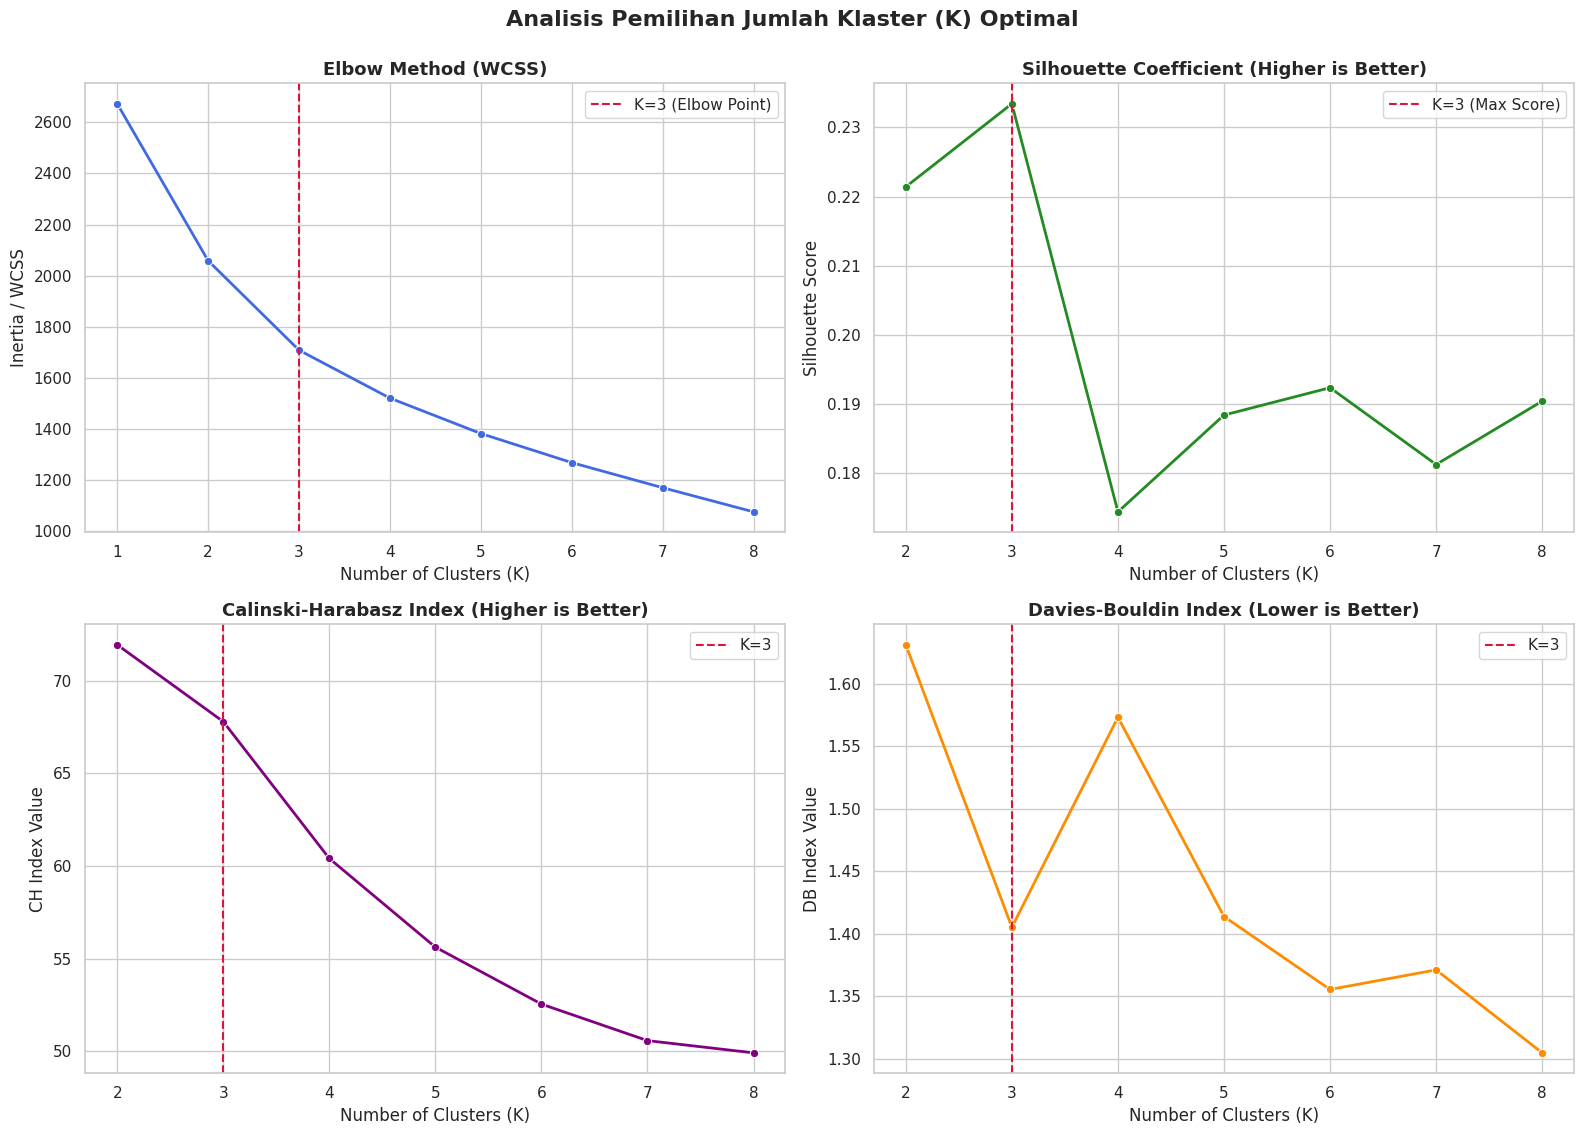

In [5]:
# Plotting metrik evaluasi menggunakan Subplots Matplotlib / Seaborn
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Elbow Method (WCSS)
sns.lineplot(x=[1] + list(k_values), y=[wcss_k1] + wcss_list, marker='o', ax=axes[0, 0], color='royalblue', linewidth=2)
axes[0, 0].set_title('Elbow Method (WCSS)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('Inertia / WCSS')
axes[0, 0].axvline(x=3, color='crimson', linestyle='--', label='K=3 (Elbow Point)')
axes[0, 0].legend()

# 2. Silhouette Score
sns.lineplot(x=k_values, y=silhouette_list, marker='o', ax=axes[0, 1], color='forestgreen', linewidth=2)
axes[0, 1].set_title('Silhouette Coefficient (Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Number of Clusters (K)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].axvline(x=3, color='crimson', linestyle='--', label='K=3 (Max Score)')
axes[0, 1].legend()

# 3. Calinski-Harabasz Index
sns.lineplot(x=k_values, y=ch_list, marker='o', ax=axes[1, 0], color='purple', linewidth=2)
axes[1, 0].set_title('Calinski-Harabasz Index (Higher is Better)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Number of Clusters (K)')
axes[1, 0].set_ylabel('CH Index Value')
axes[1, 0].axvline(x=3, color='crimson', linestyle='--', label='K=3')
axes[1, 0].legend()

# 4. Davies-Bouldin Index
sns.lineplot(x=k_values, y=db_list, marker='o', ax=axes[1, 1], color='darkorange', linewidth=2)
axes[1, 1].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Number of Clusters (K)')
axes[1, 1].set_ylabel('DB Index Value')
axes[1, 1].axvline(x=3, color='crimson', linestyle='--', label='K=3')
axes[1, 1].legend()

plt.tight_layout()
plt.suptitle('Analisis Pemilihan Jumlah Klaster (K) Optimal', y=1.03, fontsize=16, fontweight='bold')
plt.show()


### Diskusi Hasil Metrik Evaluasi

Berdasarkan grafik metrik evaluasi di atas:
1. **Silhouette Score**: Mencapai puncak tertingginya pada **$K=3$** dengan nilai **0.2334**. Hal ini menunjukkan bahwa pemisahan kelompok secara geometris paling maksimal dan jelas terjadi saat kita menggunakan 3 klaster.
2. **Elbow Method (WCSS)**: Terlihat penurunan WCSS melambat secara signifikan setelah **$K=3$**, membentuk "siku" (Elbow) di titik tersebut.
3. **Calinski-Harabasz Index**: Meskipun nilai CH sedikit lebih tinggi pada $K=2$ dibanding $K=3$ (71.94 vs 67.79), namun $K=3$ tetap memberikan pemisahan yang sangat baik dan menghasilkan granularitas yang jauh lebih relevan secara bisnis dibanding $K=2$.
4. **Davies-Bouldin Index**: Menunjukkan penurunan yang signifikan (lebih rendah lebih baik) pada **$K=3$** (1.4053) dibandingkan dengan $K=2$ (1.6313) dan $K=4$ (1.5732), di mana nilai DB yang lebih rendah mengindikasikan pemisahan klaster yang lebih baik.

**Kesimpulan**: Pemilihan **$K=3$** sangat didukung secara matematis oleh metrik Silhouette dan Davies-Bouldin, serta sangat selaras dengan kebutuhan praktis pemetaan kerentanan banjir menjadi tingkat **Rendah**, **Sedang**, dan **Tinggi**.


### Eksekusi K-Means ($K=3$) & Perhitungan Skor Kerentanan

Setelah menetapkan $K=3$, kita melatih model K-Means akhir.
Untuk mengaitkan hasil klasterisasi dengan tingkat kerentanan yang sesungguhnya (karena label K-Means default `0, 1, 2` bersifat acak secara urutan), kita menghitung **Skor Kerentanan (Vulnerability Score)** menggunakan rata-rata terarah dari fitur terstandarisasi:

$$\text{Skor Kerentanan} = \frac{1}{M}\sum_{j=1}^{M} (Z_j \times d_j)$$

Di mana:
* $Z_j$ adalah nilai terstandarisasi (*z-score*) untuk fitur ke-$j$.
* $d_j$ adalah arah pengaruh risiko untuk fitur ke-$j$ (`RISK_DIRECTIONS`), yaitu `+1` jika meningkatkan kerentanan (misalnya curah hujan, frekuensi banjir) dan `-1` jika menurunkan kerentanan (evapotranspirasi).

Klaster diurutkan berdasarkan rata-rata Skor Kerentanan:
* Skor terendah $\rightarrow$ **Rendah**
* Skor menengah $\rightarrow$ **Sedang**
* Skor tertinggi $\rightarrow$ **Tinggi**


In [6]:
def compute_vulnerability_score(scaled_features: pd.DataFrame) -> pd.Series:
    directional = scaled_features.copy()
    for col, direction in RISK_DIRECTIONS.items():
        directional[col] = directional[col] * direction
    return directional.mean(axis=1)

def assign_cluster_labels(yearly: pd.DataFrame) -> pd.DataFrame:
    # Urutkan cluster berdasarkan rata-rata skor kerentanan untuk mengurutkan label secara logis
    cluster_scores = yearly.groupby("cluster_id_raw")["skor_kerentanan"].mean().sort_values()
    label_map = {cluster_id: LABEL_ORDER[idx] for idx, cluster_id in enumerate(cluster_scores.index)}
    result = yearly.copy()
    result["cluster_label"] = result["cluster_id_raw"].map(label_map)
    result["cluster_color"] = result["cluster_label"].map(COLOR_MAP)
    return result

# Fit model K-Means K=3
model_final = KMeans(n_clusters=3, random_state=42, n_init=20)
cluster_ids = model_final.fit_predict(scaled_array)

yearly_df = prepared_df.copy()
yearly_df["cluster_id_raw"] = cluster_ids
yearly_df["skor_kerentanan"] = compute_vulnerability_score(scaled_df)
yearly_df = assign_cluster_labels(yearly_df)

final_silhouette = silhouette_score(scaled_array, cluster_ids)
print(f"K-Means training selesai. Silhouette Score Akhir: {final_silhouette:.4f}")
yearly_df.head()


K-Means training selesai. Silhouette Score Akhir: 0.2334


,kode_kemendagri,nama_clean,tahun,lat,lon,jumlah_banjir,jumlah_kejadian_bnpb,rasio_banjir_per_hujan,total_hujan_tahunan_mm,rainy_days,total_hari_hujan_ekstrem,max_hujan_harian_mm,rain_intensity_mm_per_hour_avg,avg_kelembaban_tanah,et0_fao_evapotranspiration_mm_avg,jumlah_sampah_ton_per_tahun,cluster_id_raw,skor_kerentanan,cluster_label,cluster_color
0,3201,KABUPATEN BOGOR,2015,-6.5971,106.806,5,6.0,0.002147,2328.5,291,1,52.2,0.675792,0.416822,3.812963,861919.33,0,-0.084158,Rendah,#FEE8C8
1,3201,KABUPATEN BOGOR,2016,-6.5971,106.806,18,11.0,0.004662,3860.9,360,4,79.9,0.970326,0.471384,3.291003,869475.10,1,1.042803,Sedang,#FDBB84
2,3201,KABUPATEN BOGOR,2017,-6.5971,106.806,20,12.0,0.009511,2102.8,335,0,48.2,0.745553,0.416730,3.666712,878169.85,2,0.461208,Tinggi,#E34A33
3,3201,KABUPATEN BOGOR,2018,-6.5971,106.806,4,13.0,0.002207,1812.3,320,1,55.1,0.621078,0.412137,3.883034,360813.45,0,-0.146098,Rendah,#FEE8C8
4,3201,KABUPATEN BOGOR,2019,-6.5971,106.806,10,18.0,0.004667,2142.6,313,5,127.3,0.588698,0.400083,4.066152,776610.50,2,0.421172,Tinggi,#E34A33


### Profiling Klaster dan Ringkasan Wilayah

Kita akan merangkum hasil klasterisasi menjadi dua keluaran analisis:
1. **Ringkasan Tingkat Wilayah (`cluster_wilayah_summary.csv`)**: Mengelompokkan data tahunan untuk setiap kabupaten/kota dengan menghitung rata-rata skor kerentanan, banjir, cuaca ekstrem, dan sampah, serta menentukan label klaster dominan selama periode 2015-2023.
2. **Profil Karakteristik Klaster (`cluster_profile.csv`)**: Menganalisis nilai rata-rata tiap fitur untuk klaster Rendah, Sedang, dan Tinggi untuk memberikan interpretasi taktis.


In [7]:
def dominant_label(labels: pd.Series) -> str:
    counts = labels.value_counts()
    if counts.empty:
        return "Rendah"
    tied = counts[counts == counts.max()].index.tolist()
    # Prioritaskan label yang lebih tinggi jika terjadi tie
    priority = {"Tinggi": 3, "Sedang": 2, "Rendah": 1}
    return sorted(tied, key=lambda label: priority[label], reverse=True)[0]

def build_region_summary(yearly: pd.DataFrame) -> pd.DataFrame:
    grouped = yearly.groupby(["kode_kemendagri", "nama_clean", "lat", "lon"], as_index=False)
    summary = grouped.agg(
        skor_kerentanan_rata2=("skor_kerentanan", "mean"),
        avg_jumlah_banjir=("jumlah_banjir", "mean"),
        avg_total_hari_hujan_ekstrem=("total_hari_hujan_ekstrem", "mean"),
        avg_jumlah_sampah_ton_per_tahun=("jumlah_sampah_ton_per_tahun", "mean"),
    )
    dominant = grouped["cluster_label"].agg(dominant_label).rename(columns={"cluster_label": "cluster_label"})
    summary = summary.merge(dominant, on=["kode_kemendagri", "nama_clean", "lat", "lon"], how="left")
    summary["cluster_dominan"] = summary["cluster_label"]
    summary["cluster_color"] = summary["cluster_label"].map(COLOR_MAP)
    return summary.sort_values("skor_kerentanan_rata2", ascending=False).reset_index(drop=True)

def build_cluster_profile(yearly: pd.DataFrame, silhouette: float) -> pd.DataFrame:
    profile = yearly.groupby("cluster_label", as_index=False).agg(
        jumlah_observasi=("cluster_label", "size"),
        avg_skor_kerentanan=("skor_kerentanan", "mean"),
        avg_jumlah_banjir=("jumlah_banjir", "mean"),
        avg_jumlah_kejadian_bnpb=("jumlah_kejadian_bnpb", "mean"),
        avg_total_hujan_tahunan_mm=("total_hujan_tahunan_mm", "mean"),
        avg_total_hari_hujan_ekstrem=("total_hari_hujan_ekstrem", "mean"),
        avg_max_hujan_harian_mm=("max_hujan_harian_mm", "mean"),
        avg_kelembaban_tanah=("avg_kelembaban_tanah", "mean"),
        avg_et0=("et0_fao_evapotranspiration_mm_avg", "mean"),
        avg_jumlah_sampah_ton_per_tahun=("jumlah_sampah_ton_per_tahun", "mean"),
    )
    profile["cluster_color"] = profile["cluster_label"].map(COLOR_MAP)
    profile["silhouette_score"] = silhouette
    profile["interpretasi"] = profile["cluster_label"].map(
        {
            "Rendah": "Kerentanan relatif rendah berdasarkan kombinasi banjir, hujan ekstrem, dan sampah.",
            "Sedang": "Kerentanan menengah dengan beberapa indikator risiko meningkat.",
            "Tinggi": "Kerentanan tinggi dengan kombinasi histori banjir, tekanan cuaca, dan sampah lebih berat.",
        }
    )
    order = {label: idx for idx, label in enumerate(LABEL_ORDER)}
    profile["_order"] = profile["cluster_label"].map(order)
    return profile.sort_values("_order").drop(columns="_order").reset_index(drop=True)

# Membangun Ringkasan dan Profil
summary_df = build_region_summary(yearly_df)
profile_df = build_cluster_profile(yearly_df, final_silhouette)

print("--- PROFIL KLASTER KERENTANAN BANJIR (SUMMARY) ---")
profile_df


--- PROFIL KLASTER KERENTANAN BANJIR (SUMMARY) ---


,cluster_label,jumlah_observasi,avg_skor_kerentanan,avg_jumlah_banjir,avg_jumlah_kejadian_bnpb,avg_total_hujan_tahunan_mm,avg_total_hari_hujan_ekstrem,avg_max_hujan_harian_mm,avg_kelembaban_tanah,avg_et0,avg_jumlah_sampah_ton_per_tahun,cluster_color,silhouette_score,interpretasi
0,Rendah,105,-0.482926,3.923810,2.352381,2096.381905,1.790476,66.779048,0.304263,4.050410,257557.764476,#FEE8C8,0.233409,Kerentanan relatif rendah berdasarkan kombinas...
1,Sedang,117,0.313696,6.863248,4.268661,3334.754701,3.931624,86.927350,0.384122,3.451426,293717.613162,#FDBB84,0.233409,Kerentanan menengah dengan beberapa indikator ...
2,Tinggi,21,0.666894,27.952381,19.709524,2481.580952,3.047619,79.690476,0.348375,3.698558,395721.284762,#E34A33,0.233409,Kerentanan tinggi dengan kombinasi histori ban...


### Visualisasi Tingkat Lanjut (Premium Visualizations)

Untuk menyajikan hasil klasterisasi dengan daya tarik visual yang tinggi (*premium aesthetics*), bagian ini menyajikan:
1. **PCA 2D Cluster Scatter Plot**: Memproyeksikan data multi-dimensi menjadi dua komponen utama agar kita bisa melihat bagaimana K-Means secara geometris membagi daerah-daerah tersebut.
2. **Radar Chart (Karakteristik Profil)**: Menampilkan profil rata-rata fitur yang terstandardisasi untuk setiap klaster. Ini membantu kita melihat secara langsung fitur apa yang paling dominan di setiap klaster.
3. **Box Plot Distribusi Fitur**: Memperlihatkan sebaran data riil dari fitur-fitur kunci seperti `jumlah_banjir`, `total_hari_hujan_ekstrem`, dan `jumlah_sampah_ton_per_tahun` untuk masing-masing klaster.


In [8]:
# Proyeksi PCA 2D
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(scaled_array)
yearly_df['pca_1'] = pca_coords[:, 0]
yearly_df['pca_2'] = pca_coords[:, 1]

# Interactive Plotly Scatter Plot
fig_pca = px.scatter(
    yearly_df,
    x='pca_1',
    y='pca_2',
    color='cluster_label',
    color_discrete_map=COLOR_MAP,
    category_orders={"cluster_label": ["Rendah", "Sedang", "Tinggi"]},
    hover_data=['nama_clean', 'tahun', 'skor_kerentanan'],
    title="Proyeksi 2D PCA Klaster Kerentanan Banjir Jabar (2015-2023)"
)

fig_pca.update_layout(
    xaxis_title=f"PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
    legend_title="Tingkat Kerentanan",
    plot_bgcolor='rgba(240,240,240,0.5)',
    paper_bgcolor='white',
    font=dict(family="Outfit, Inter, sans-serif", size=12)
)
fig_pca.show()


In [9]:
# Menghitung rata-rata z-score per klaster untuk radar chart
scaled_df_with_labels = scaled_df.copy()
scaled_df_with_labels['cluster_label'] = yearly_df['cluster_label'].values
cluster_means = scaled_df_with_labels.groupby('cluster_label').mean()

# Reorder index to match labeling order
cluster_means = cluster_means.reindex(["Rendah", "Sedang", "Tinggi"])

# Plotting Radar Chart dengan Plotly
fig_radar = go.Figure()

for label in ["Rendah", "Sedang", "Tinggi"]:
    fig_radar.add_trace(go.Scatterpolar(
        r=cluster_means.loc[label].values,
        theta=[col.replace('_', ' ').title() for col in cluster_means.columns],
        fill='toself',
        name=label,
        line_color=COLOR_MAP[label]
    ))

fig_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[cluster_means.values.min() - 0.2, cluster_means.values.max() + 0.2],
            showticklabels=True,
            ticks="outside"
        ),
        angularaxis=dict(
            direction="clockwise",
            period=len(cluster_means.columns)
        )
    ),
    showlegend=True,
    legend_title="Tingkat Kerentanan",
    title=dict(
        text="Profil Fitur Terstandarisasi per Klaster Kerentanan (Z-Score)",
        font=dict(family="Outfit, Inter, sans-serif", size=16, color="black"),
        x=0.5,
        y=0.95
    ),
    width=900,
    height=650,
    font=dict(family="Outfit, Inter, sans-serif", size=11)
)
fig_radar.show()


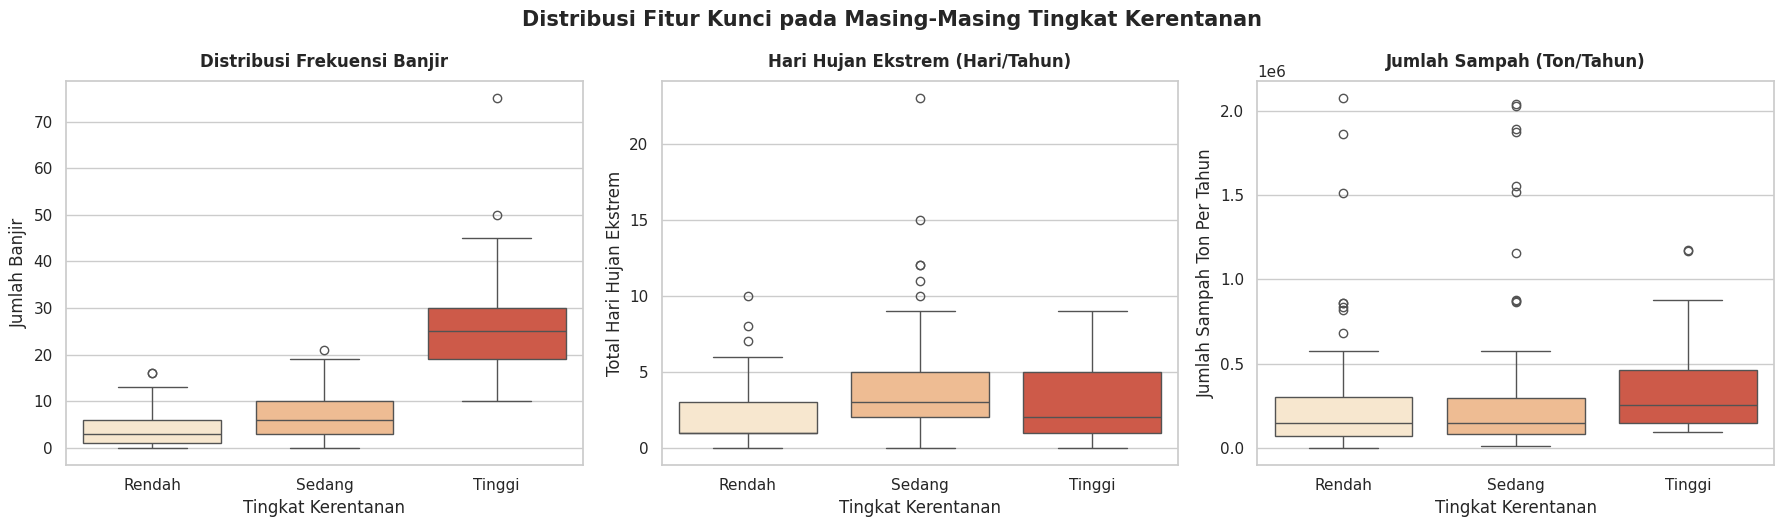

In [10]:
# Setup 1x3 subplots untuk fitur utama
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features_to_plot = ["jumlah_banjir", "total_hari_hujan_ekstrem", "jumlah_sampah_ton_per_tahun"]
feature_titles = ["Distribusi Frekuensi Banjir", "Hari Hujan Ekstrem (Hari/Tahun)", "Jumlah Sampah (Ton/Tahun)"]

for idx, (feat, title) in enumerate(zip(features_to_plot, feature_titles)):
    sns.boxplot(
        data=yearly_df,
        x="cluster_label",
        y=feat,
        order=["Rendah", "Sedang", "Tinggi"],
        palette=COLOR_MAP,
        hue="cluster_label",
        legend=False,
        ax=axes[idx]
    )
    axes[idx].set_title(title, fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel("Tingkat Kerentanan")
    axes[idx].set_ylabel(feat.replace('_', ' ').title())

plt.tight_layout()
plt.suptitle('Distribusi Fitur Kunci pada Masing-Masing Tingkat Kerentanan', y=1.05, fontsize=15, fontweight='bold')
plt.show()


### Penyimpanan Hasil Output (Export to CSV)

Di bagian akhir ini, kita akan menyimpan hasil klasterisasi ke direktori `data/processed/` sesuai dengan skema output dashboard:
* **`cluster_tahunan_2015_2023.csv`**: Data mentah tahunan beserta kolom `cluster_label`, `skor_kerentanan`, dan `cluster_color`.
* **`cluster_wilayah_summary.csv`**: Rangkuman per wilayah (agregasi 2015–2023) untuk visualisasi choropleth map.
* **`cluster_profile.csv`**: Rangkuman statistik deskriptif rata-rata fitur per klaster beserta interpretasinya.


In [11]:
def write_outputs(yearly: pd.DataFrame, summary: pd.DataFrame, profile: pd.DataFrame) -> None:
    # Buat direktori output jika belum ada
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    yearly.to_csv(YEARLY_OUTPUT, index=False)
    summary.to_csv(SUMMARY_OUTPUT, index=False)
    profile.to_csv(PROFILE_OUTPUT, index=False)

write_outputs(yearly_df, summary_df, profile_df)

print(f"Ekspor berhasil dilakukan!")
print(f"1. Rincian Tahunan: {YEARLY_OUTPUT.resolve()} ({len(yearly_df)} baris)")
print(f"2. Ringkasan Wilayah: {SUMMARY_OUTPUT.resolve()} ({len(summary_df)} baris)")
print(f"3. Profil Klaster: {PROFILE_OUTPUT.resolve()} ({len(profile_df)} baris)")


Ekspor berhasil dilakukan!
1. Rincian Tahunan: /home/ikhbar/Documents/GitHub/II4013-Tubes-Data-Analytics-Banjir-Jawa-Barat/data/processed/cluster_tahunan_2015_2023.csv (243 baris)
2. Ringkasan Wilayah: /home/ikhbar/Documents/GitHub/II4013-Tubes-Data-Analytics-Banjir-Jawa-Barat/data/processed/cluster_wilayah_summary.csv (27 baris)
3. Profil Klaster: /home/ikhbar/Documents/GitHub/II4013-Tubes-Data-Analytics-Banjir-Jawa-Barat/data/processed/cluster_profile.csv (3 baris)
